In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [5]:
# Reshape data for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Normalize pixel values (0 to 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Preprocessing completed")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Preprocessing completed
X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Second Convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer (10 classes for digits 0-9)
model.add(Dense(10, activation='softmax'))

print("CNN Model created successfully")

CNN Model created successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully")

Model compiled successfully


In [8]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.9362 - loss: 0.2073 - val_accuracy: 0.9857 - val_loss: 0.0460
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9768 - loss: 0.0767 - val_accuracy: 0.9884 - val_loss: 0.0333
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9822 - loss: 0.0586 - val_accuracy: 0.9913 - val_loss: 0.0274
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9857 - loss: 0.0480 - val_accuracy: 0.9920 - val_loss: 0.0239
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9881 - loss: 0.0379 - val_accuracy: 0.9891 - val_loss: 0.0304


In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9891 - loss: 0.0304
Test Loss: 0.030435271561145782
Test Accuracy: 0.9890999794006348


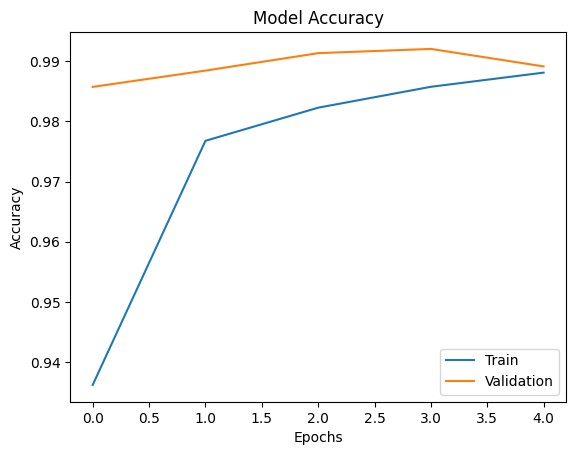

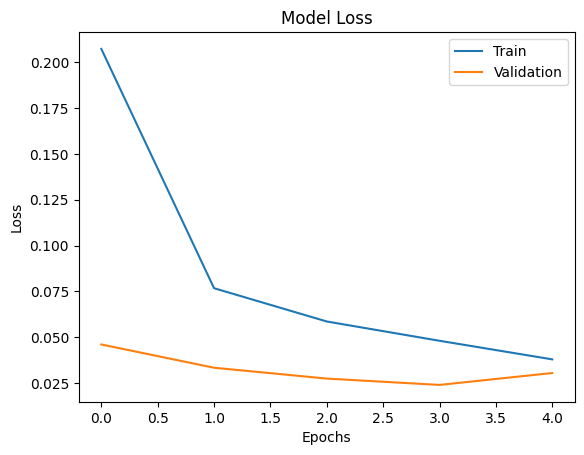

In [10]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [11]:
import numpy as np

for i in range(5):
    img = X_test[i]
    prediction = model.predict(img.reshape(1, 28, 28, 1))

    print("Predicted:", np.argmax(prediction))
    print("Actual:", y_test[i])
    print("------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted: 7
Actual: 7
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted: 2
Actual: 2
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: 1
Actual: 1
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted: 0
Actual: 0
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: 4
Actual: 4
------


In [12]:
model.save("handwritten_character_recognition.h5")

print("Model saved successfully as .h5 file")

Model saved successfully as .h5 file
